# Загрузка датасета

In [1]:
import kagglehub
import pandas as pd
import os

def path_to_csv(path, index_file=0, separator = ','):
    files = os.listdir(path)
    csv_file = [file for file in files if file.endswith(".csv")]
    if csv_file:
        df = pd.read_csv(os.path.join(path, csv_file[index_file]), sep=separator)
        return df
    else:
        print("CSV файл не найден в загруженном датасете.")

# Download latest version
path_1 = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")
df_1 = path_to_csv(path_1, index_file = 1)
df_2 = path_to_csv(path_1, index_file = 0)


# замержи df_1 и df_2 по track_id
df_merged = pd.merge(df_1, df_2, on='track_id')
df_merged = df_merged[['user_id', 'track_id', 'tags', 'year', 'duration_ms']]
df = df_merged
df.head()

c:\Users\krasn\source\repos\SHAD_MTS_24_25\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,user_id,track_id,tags,year,duration_ms
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRIRLYL128F42539D1,"soul, funk, piano, 70s, oldies",2010,155453
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRFUPBA128F934F7E1,"electronic, pop, female_vocalists, dance, pian...",2012,260000
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRLQPQJ128F42AA94F,guitar,2003,187106
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRTUCUY128F92E1D24,"rock, alternative, alternative_rock, hard_rock...",1999,256440
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRHDDQG12903CB53EE,"electronic, female_vocalists, ambient, chillou...",2002,250360


## 1. Формирование гипотез

### Гипотезы по дискретному показателю:

1. **Гипотеза о равенстве распределений (для двух групп):**
   - $H_0$: Распределения дискретного показателя, а именно `year`, одинаковы для двух сегментов (`rock` и `alternative`).
   - $H_1$: Распределения различаются.

2. **Гипотеза о равенстве медиан:**
   - $H_0$: Медианы дискретного показателя(`year`) одинаковы для двух сегментов (`rock` и `alternative`).
   - $H_1$: Медианы различаются.

---

### Гипотезы по непрерывному показателю:

3. **Гипотеза о равенстве распределений (для двух групп):**
   - $H_0$: Распределения непрерывного показателя(`duration`) одинаковы для двух сегментов (`rock` и `alternative`).
   - $H_1$: Распределения различаются.

4. **Гипотеза о равенстве медиан:**
   - $H_0$: Медианы непрерывного показателя(`duration`) одинаковы для двух сегментов (`rock` и `alternative`).
   - $H_1$: Медианы различаются.



## 2. Проверка гипотез

Для начала, соберем датасеты по двум выборкам и посмотрим общую статитиску по выборкам и как распределились данные.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
name_segments = ['rock', 'pop']

df = df.dropna(subset=['tags'])
segments = {}
segments['duration'] = {segment: df[df['tags'].str.contains(segment)]['duration_ms'].div(1000).sample(n=5000)
                        for segment in name_segments}

segments['year'] = {segment: df[df['tags'].str.contains(segment)]['year'].sample(n=5000)
                    for segment in name_segments}


Histograms:


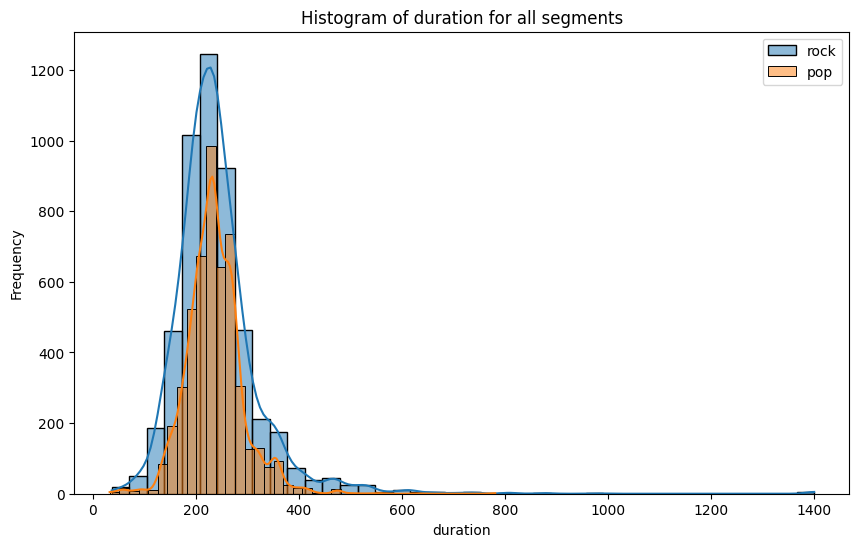

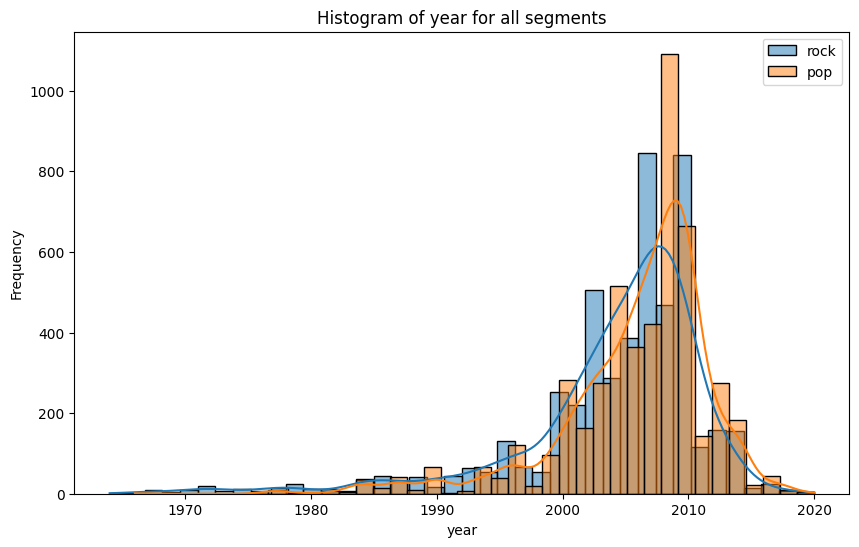

In [4]:
print("\nHistograms:")
for metric, data_dict in segments.items():
    plt.figure(figsize=(10, 6))
    for segment, data in data_dict.items():
        sns.histplot(data, kde=True, label=segment, bins=40)
    plt.title(f"Histogram of {metric} for all segments")
    plt.xlabel(metric)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


QQ-plot of duration and rock


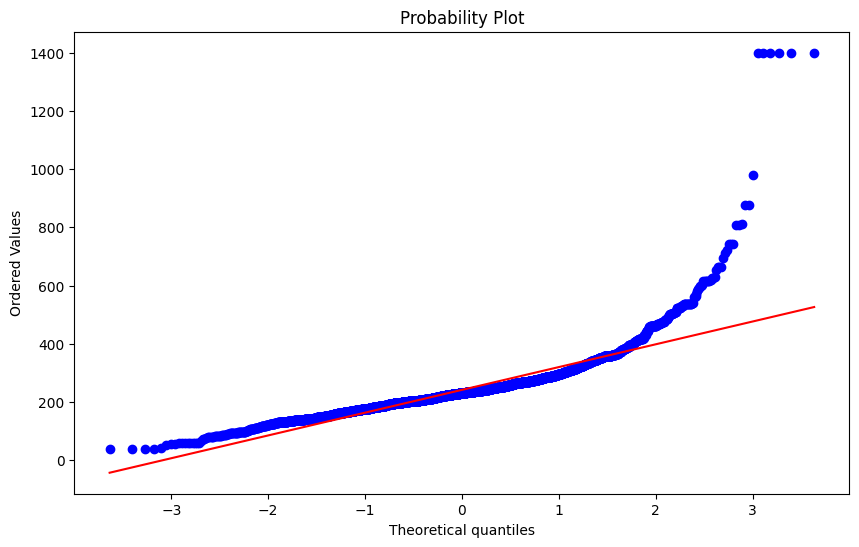

QQ-plot of duration and pop


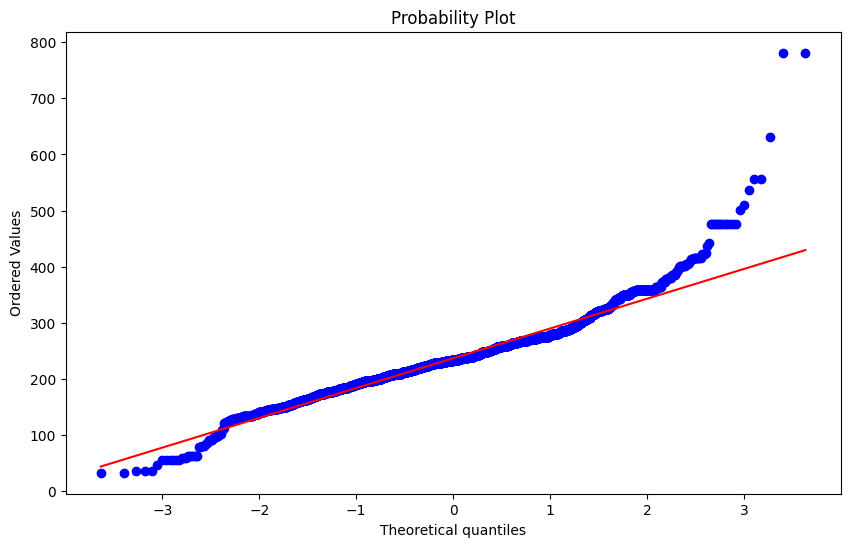

In [5]:
for segment, data in segments['duration'].items():
    plt.figure(figsize=(10, 6))
    print(f"QQ-plot of duration and {segment}")
    stats.probplot(data, dist="norm", plot=plt);
    plt.show()

In [6]:
for metric, data_dict in segments.items():
    for segment, data in data_dict.items():
        print(f"{metric} {segment}:")
        print(data.describe())
        print()


duration rock:
count    5000.000000
mean      241.246889
std        89.320569
min        36.720000
25%       195.640000
50%       230.159500
75%       268.986000
max      1400.466000
Name: duration_ms, dtype: float64

duration pop:
count    5000.000000
mean      236.604632
std        54.597698
min        32.626000
25%       204.846000
50%       232.720000
75%       265.813000
max       781.253000
Name: duration_ms, dtype: float64

year rock:
count    5000.000000
mean     2004.078400
std         7.532649
min      1964.000000
25%      2002.000000
50%      2006.000000
75%      2009.000000
max      2020.000000
Name: year, dtype: float64

year pop:
count    5000.000000
mean     2005.923400
std         6.037021
min      1966.000000
25%      2003.000000
50%      2007.000000
75%      2010.000000
max      2020.000000
Name: year, dtype: float64



### Гипотеза 1
- $H_0$: Распределения дискретного показателя, а именно `year`, одинаковы для двух сегментов (`rock` и `alternative`).
- $H_1$: Распределения различаются.

Для дискретного показателя лучше всего подойдет хи-квадрат проверка, чем, например, тест Колмогорома-Смирнова.

In [7]:
# Подсчет количества лет для каждого сегмента
segments_year_count = {
    segment: segments['year'][segment].value_counts()
    for segment in name_segments
}

year_count_df = pd.DataFrame(segments_year_count).fillna(0)

# Транспонируем для горизонтального представления
year_count_df = year_count_df.T

# Вывод таблицы
print("Группировка по годам для каждого сегмента:")
print(year_count_df)

Группировка по годам для каждого сегмента:
year  1964  1965  1966  1967  1968  1969  1970  1971  1972  1973  ...   2011  \
rock   1.0   1.0   2.0   6.0   3.0   4.0   8.0   7.0  13.0   7.0  ...  117.0   
pop    0.0   0.0   1.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0  ...  144.0   

year   2012  2013   2014  2015  2016  2017  2018  2019  2020  
rock  159.0  86.0   69.0  15.0  18.0   6.0   7.0   4.0   1.0  
pop   217.0  57.0  182.0  22.0  10.0  34.0   9.0   2.0   2.0  

[2 rows x 57 columns]


In [8]:
from scipy.stats import chi2_contingency
chi, pvalue, k, _ = chi2_contingency(year_count_df.values)

print(f'chi_square: pvalue = {pvalue}')

chi_square: pvalue = 1.858493207163821e-67


**Вывод:** Гипотеза $H_0$ об одинаковом распределении отвергается.

### Гипотеза 2
- $H_0$: Медианы дискретного показателя(`year`) одинаковы для двух сегментов (`rock` и `alternative`).
- $H_1$: Медианы различаются.

Для проверки одинаковости медиан взял Медианный тест.

In [9]:
import numpy as np
from scipy.stats import chi2_contingency

def median_test(sample1, sample2):
    # Объединяем обе выборки и находим общую медиану
    combined = np.concatenate([sample1, sample2])
    overall_median = np.median(combined)

    # Подсчитываем, сколько элементов в каждой выборке выше/ниже или равны медиане
    table = [
        [np.sum(sample1 > overall_median), np.sum(sample1 <= overall_median)],
        [np.sum(sample2 > overall_median), np.sum(sample2 <= overall_median)]
    ]

    # Используем хи-квадрат тест для таблицы сопряжённости
    chi2, p_value, _, _ = chi2_contingency(table)

    return chi2, p_value

group1 = segments['year']['rock']
group2 = segments['year']['pop']
chi2, p_value = median_test(group1, group2)

print(f"P-значение: {p_value:.4f}")

P-значение: 0.0000


**Вывод:** Гипотеза $H_0$ об одинаковости медиан отвергается.

### Гипотеза 3
- $H_0$: Распределения непрерывного показателя(`duration`) одинаковы для двух сегментов (`rock` и `alternative`).
- $H_1$: Распределения различаются.

Для проверки будем использовать тест Манна-Уитни. Потому что выборки не нормально распределены.

In [10]:
from scipy.stats import ks_2samp, mannwhitneyu

group1 = segments['duration']['rock']
group2 = segments['duration']['pop']


_, mw_pvalue = mannwhitneyu(group1, group2)
print(f"Mann-Whitneyu: p-value={mw_pvalue}")

Mann-Whitneyu: p-value=0.003045972807178494


**Вывод:** Гипотеза $H_0$ об одинаковом распределении отвергается.

### Гипотеза 4
- $H_0$: Медианы непрерывного показателя(`duration`) одинаковы для двух сегментов (`rock` и `alternative`).
- $H_1$: Медианы различаются.

Для медиан используем Медианный тест.

In [11]:
chi2, p_value = median_test(group1, group2)

print(f"P-значение: {p_value:.4f}")

P-значение: 0.0014


**Вывод:** Гипотеза $H_0$ об одинаковости медиан отвергается.

### Бутстрап


In [12]:
import numpy as np

def bootstrap_median_diff(sample1, sample2, num_iterations=10000):
    boot_diffs = []
    for _ in range(num_iterations):
        boot_s1 = np.random.choice(sample1, size=len(sample1), replace=True)
        boot_s2 = np.random.choice(sample2, size=len(sample2), replace=True)
        boot_diffs.append(np.median(boot_s1) - np.median(boot_s2))
    lower = np.percentile(boot_diffs, 2.5)
    upper = np.percentile(boot_diffs, 97.5)
    return lower, upper

# Бутстрап для year
ci_count = bootstrap_median_diff(
    segments['year']['rock'],
    segments['year']['pop']
)
print(f"Bootstrap for year median difference: {ci_count}")

# Бутстрап для duration
ci_duration = bootstrap_median_diff(
    segments['duration']['rock'],
    segments['duration']['pop']
)
print(f"Bootstrap for duration median difference: {ci_duration}")

Bootstrap for year median difference: (np.float64(-2.0), np.float64(-1.0))
Bootstrap for duration median difference: (np.float64(-4.492999999999995), np.float64(-1.0205000000000268))


Для медиан результаты бутстрапа и тестов совпали.